IMPORT MODULE

In [1]:
!pip install catboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




Load the dataset

In [3]:
df = pd.read_csv(r"C:\Users\dell\Downloads\WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [5]:
df.shape

(7043, 21)

In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
#get category column
cat_cols = [col for col in df.columns if df[col].dtype=='object']
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [8]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#check null value
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
#drop customer id column
df = df.drop(['customerID'],axis=1)

In [11]:
#change TotalCharges to numeric datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df.isnull().sum()


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
#display null values
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
#drop rows where tenure is 0
df = df.drop(df[df['tenure'] == 0].index, axis=0)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

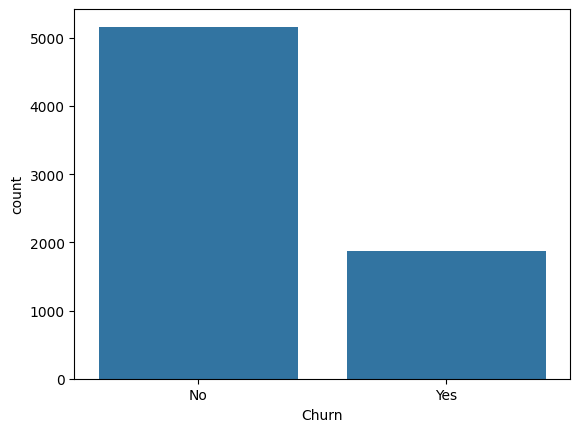

In [14]:
sns.countplot(x='Churn' , data=df);

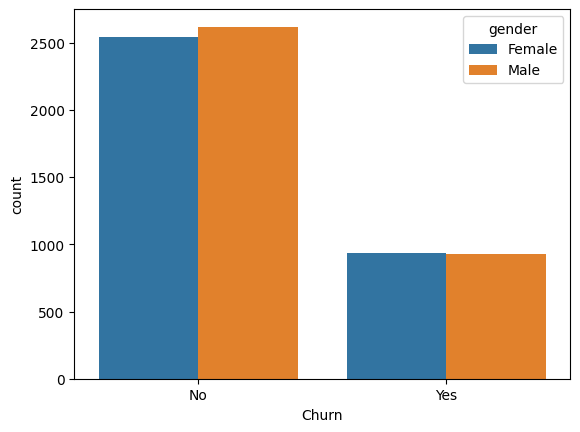

In [15]:
sns.countplot(x='Churn',hue='gender',data=df);

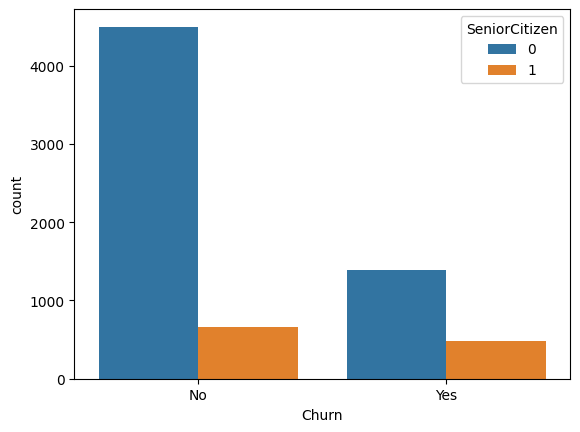

In [16]:
sns.countplot(x='Churn',hue='SeniorCitizen',data=df);

In [17]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


Senior citizens show significantly higher churn rates compared to non-senior customers

<Axes: xlabel='Churn', ylabel='count'>

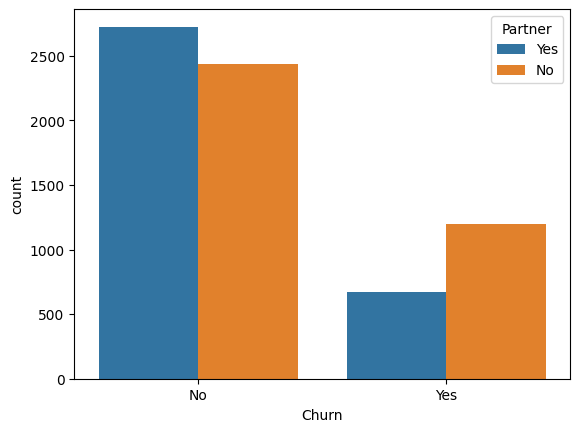

In [18]:
sns.countplot(x='Churn', hue='Partner', data=df)

people who doesn't have partner or single person more likely to get Churn

<Axes: xlabel='Churn', ylabel='count'>

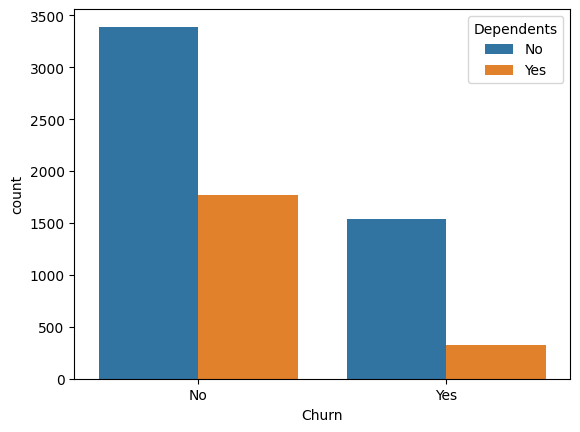

In [19]:
sns.countplot(x='Churn', hue='Dependents', data=df)

people who are not Dependent  or single person more likely to get Churn
if the customers has a family,all of them prefer to use same service and retention is high

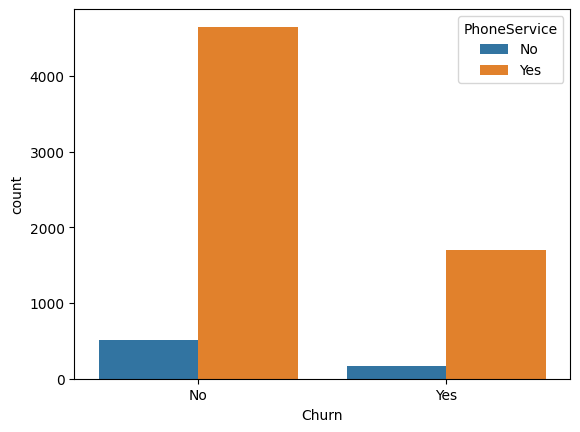

In [20]:
sns.countplot(x='Churn',hue='PhoneService',data=df);

Those who have PhoneService are more likely to Churn

<Axes: xlabel='Churn', ylabel='count'>

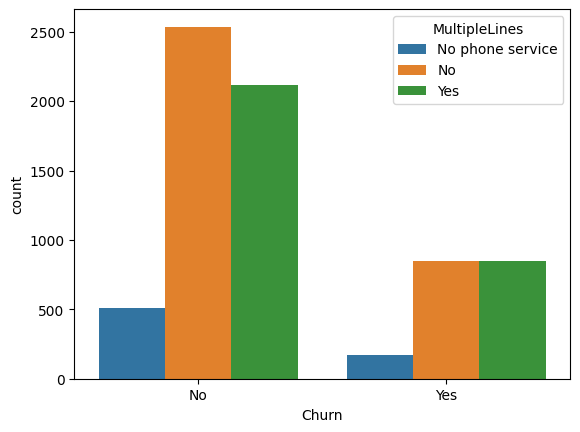

In [21]:
sns.countplot(x='Churn' , hue = 'MultipleLines' , data = df)

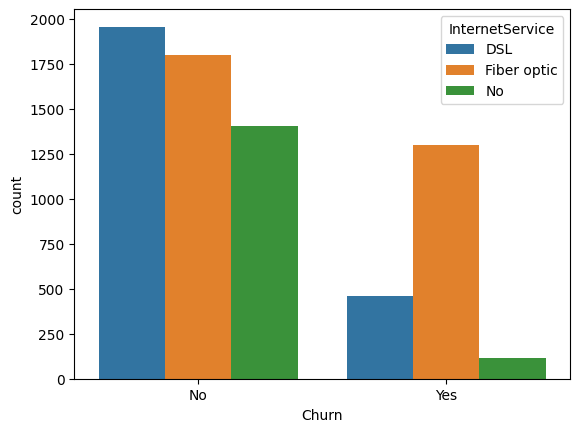

In [22]:
sns.countplot(x='Churn',hue='InternetService',data=df);

In [23]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Those who have opted for Fiber optic are more likely to Churn and on contrary ,those who have DSL service have more retention

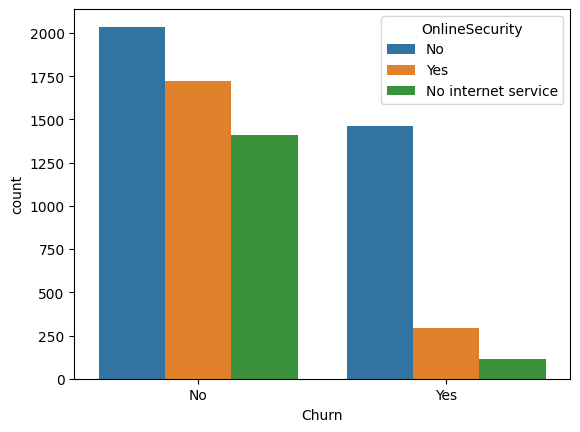

In [24]:
sns.countplot(x='Churn',hue='OnlineSecurity',data=df);

In [25]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


People who doesn't have online security are more likely to Churn

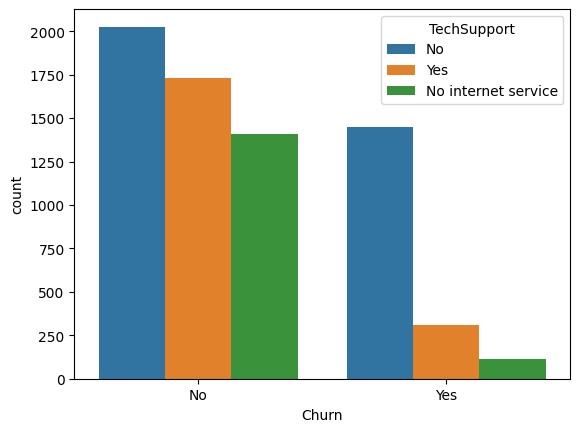

In [26]:
sns.countplot(x='Churn',hue='TechSupport',data=df);

In [27]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


People who doesn't have Tech support are more likely to Churn

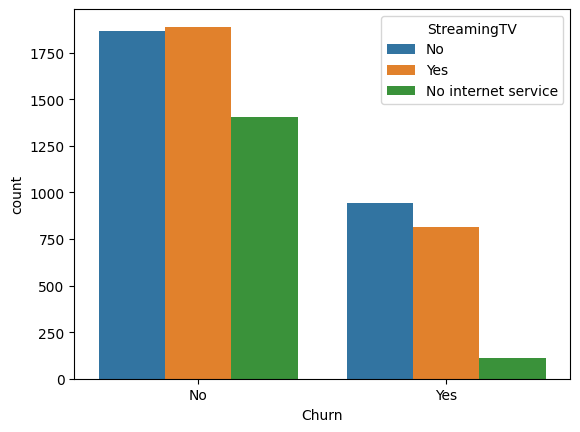

In [28]:
sns.countplot(x='Churn',hue='StreamingTV',data=df);

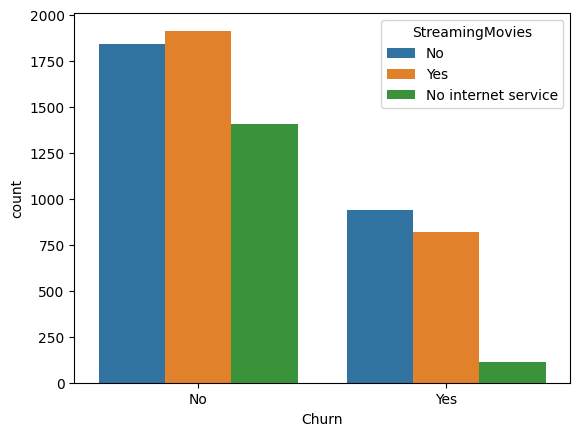

In [29]:
sns.countplot(x='Churn',hue='StreamingMovies',data=df);

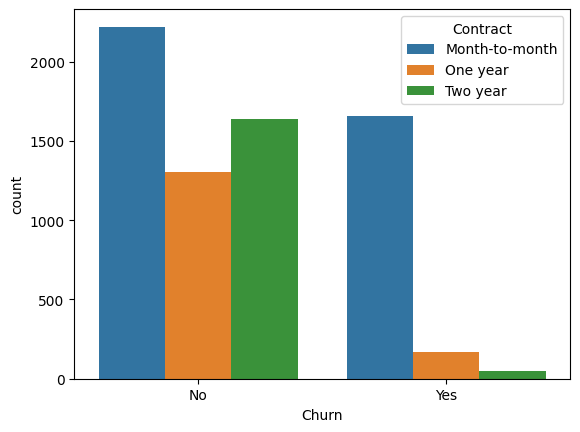

In [30]:
sns.countplot(x='Churn',hue='Contract',data=df);

In [31]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


People who are on monthly contract are more likely to churn and people who are on yearly contract less likely to Churn

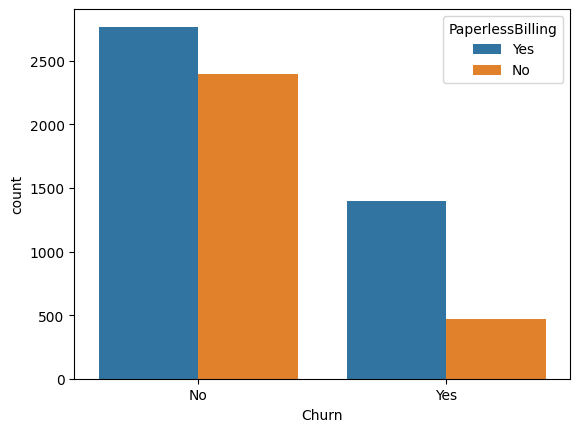

In [32]:
sns.countplot(x='Churn',hue='PaperlessBilling',data=df);

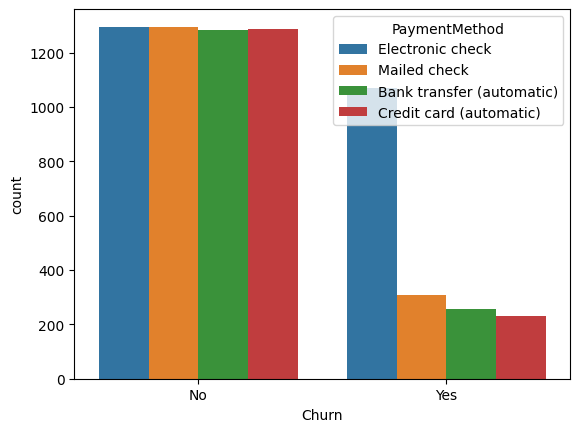

In [33]:
sns.countplot(x='Churn',hue='PaymentMethod',data=df);

In [34]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


People who have opted for electronic check payment method are more likely to Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

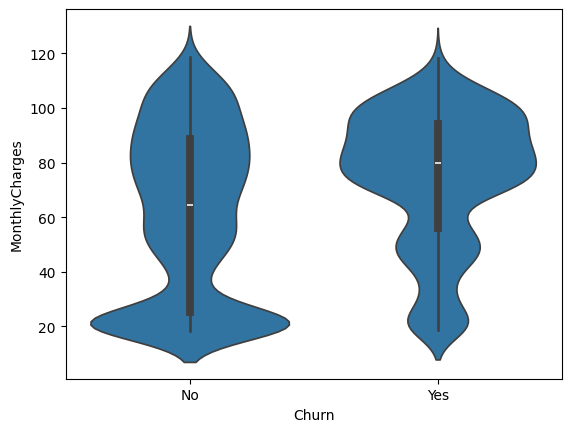

In [35]:
sns.violinplot(x='Churn', y='MonthlyCharges', data=df)

People who have high monthly charges are more likely to chrun

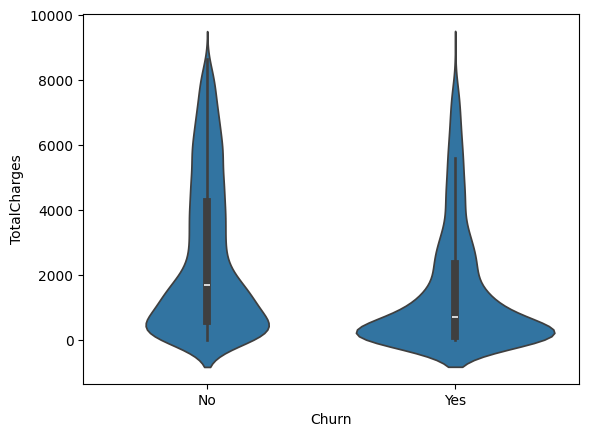

In [36]:
sns.violinplot(x='Churn',y='TotalCharges',data=df);

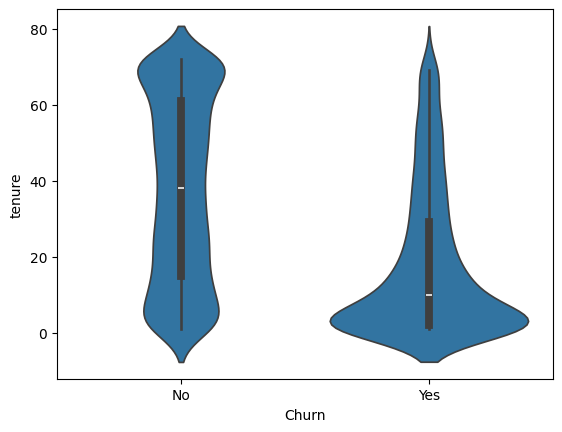

In [37]:
sns.violinplot(x='Churn',y='tenure',data=df);

People who are on low tenure or who have subscribed for less no. of month are more likely to churn

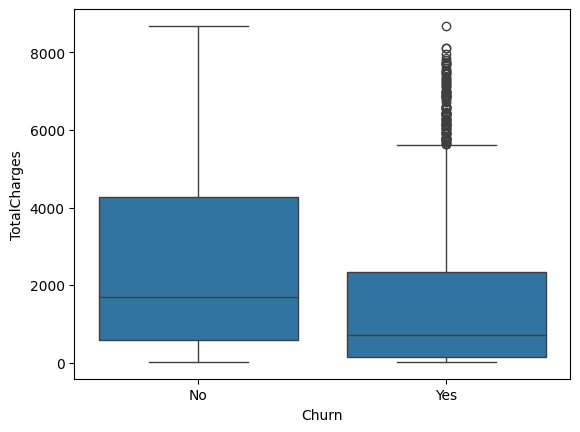

In [38]:
sns.boxplot(x='Churn',y='TotalCharges',data=df);

In [39]:
#PERFORM LOG TRANSFORMATION
df['MonthlyCharges'] = np.log(df['MonthlyCharges']+1)
df['TotalCharges'] = np.log(df['TotalCharges']+1)


<Axes: xlabel='TotalCharges', ylabel='Density'>

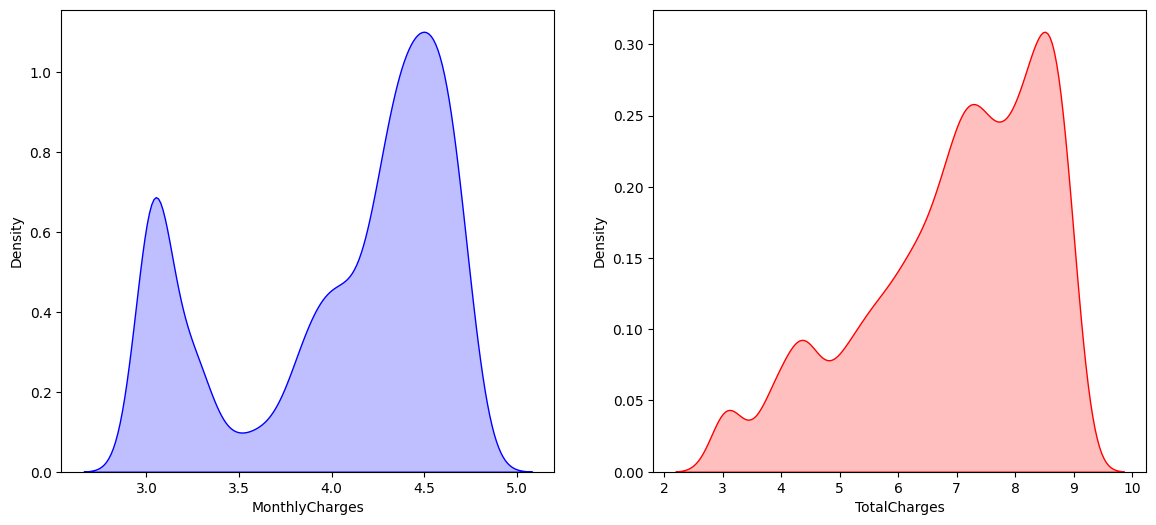

In [40]:
fig, axes = plt.subplots(1,2,figsize=(14,6))
sns.kdeplot(df['MonthlyCharges'], ax=axes[0],color='blue',shade=True)
sns.kdeplot(df['TotalCharges'], ax=axes[1],color='red',shade=True)

<Axes: >

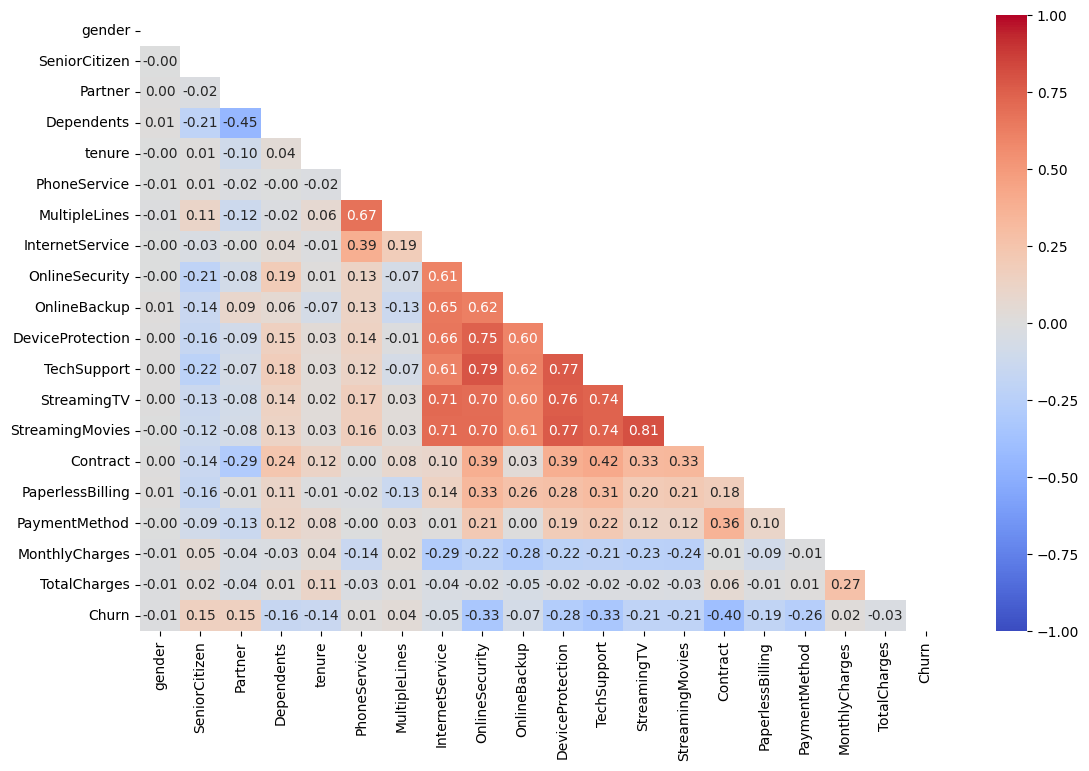

In [41]:
plt.figure(figsize=(13,8))
corr = df.apply(lambda x:pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,cmap='coolwarm',vmax=1,vmin=-1,center=0,annot=True,fmt='.2f')


In [42]:
df.apply(lambda x:pd.factorize(x)[0]if x.dtype!='float64' else x)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.429137,3.429137,0
1,1,0,1,0,1,1,1,0,1,1,1,0,0,0,1,1,1,4.059581,7.544597,0
2,1,0,1,0,2,1,1,0,1,0,0,0,0,0,0,0,1,4.004602,4.692723,1
3,1,0,1,0,3,0,0,0,1,1,1,1,0,0,1,1,2,3.768153,7.518471,0
4,0,0,1,0,2,1,1,1,0,1,0,0,0,0,0,0,0,4.272491,5.028148,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,1,65,1,2,0,1,1,1,1,1,1,1,0,1,4.452019,7.596643,0
7039,0,0,0,1,21,1,2,1,0,0,1,0,1,1,1,0,3,4.646312,8.904345,0
7040,0,0,0,1,26,0,0,0,1,1,0,0,0,0,0,0,0,3.421000,5.850621,0
7041,1,1,0,0,54,1,2,1,0,1,0,0,0,0,0,0,1,4.322807,5.728800,1


Train Test Split

In [49]:
X = df.drop(['Churn'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})
X_encoded = pd.get_dummies(X, drop_first=True)
print("Done!")

Done!


In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Done!")

Done!


Model Training

Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_train, y_train)
lr_pred = model_lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.74      1407

ROC-AUC: 0.8413749993529049


Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)
rf_pred = model_rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

ROC-AUC: 0.8173509481236831


CatBoost

In [47]:
from catboost import CatBoostClassifier

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_cb = CatBoostClassifier(verbose=False)
model_cb.fit(X_train_cb, y_train_cb, cat_features=cat_cols)
cb_pred = model_cb.predict(X_test_cb)

print("CatBoost")
print(classification_report(y_test_cb, cb_pred))
print("ROC-AUC:", roc_auc_score(y_test_cb, model_cb.predict_proba(X_test_cb)[:,1]))


CatBoost
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC: 0.8356611499655745


In [48]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'CatBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test_cb, cb_pred)
    ]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.729922
1        Random Forest  0.786070
2             CatBoost  0.791045
